# M2: additivity hypothesis exploration

`PLANhue.md` M2, Goal 3 in `hue_sensor_experiment_notes.md`: does a multi-channel flashDiff/ condition equal the sum of its single-channel conditions, once the shared `NN` (nothing-flashes) environmental offset is corrected for? Uses the M2-confirmed aggregation (`aggregate.aggregate_trials`, trim=5 samples off each end of every `Stim` block -- grid and baseline alike) and `aggregate.additivity_prediction`, which leaves the offset correction (`offset_multiplier`) as a free parameter rather than assuming the `(k-1)` scaling -- that's exactly what this notebook is checking.

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd
import matplotlib.pyplot as plt

import aggregate
import loader
import plotting

df = loader.load_flashdiff()
agg = aggregate.aggregate_trials(df, group_cols=['condition', 'Stim'])
agg.groupby('condition').size()

condition
G        106
GY       106
NN       106
R        106
RG       106
RGY      106
RGY_1    101
RY       106
Y        106
dtype: int64

## Candidate models

Two-component conditions (`GY`, `RY`, `RG`) against their two single-channel components, offset corrected once (`offset_multiplier=1`); three-component `RGY` against three different decompositions the working hypothesis names -- `R+G+Y`, `RG+Y`, `RY+G` -- each tried at both `offset_multiplier=1` (flat) and `2` (`k-1` scaling, one extra NN copy per extra summed condition).

In [2]:
CANDIDATES = [
    ('GY ~ G+Y, x1', ['G', 'Y'], 'GY', 1),
    ('RY ~ R+Y, x1', ['R', 'Y'], 'RY', 1),
    ('RG ~ R+G, x1', ['R', 'G'], 'RG', 1),
    ('RGY ~ R+G+Y, x1', ['R', 'G', 'Y'], 'RGY', 1),
    ('RGY ~ R+G+Y, x2', ['R', 'G', 'Y'], 'RGY', 2),
    ('RGY ~ RG+Y, x1', ['RG', 'Y'], 'RGY', 1),
    ('RGY ~ RY+G, x1', ['RY', 'G'], 'RGY', 1),
]

def residual_summary(label, components, target, offset_multiplier):
    pred = aggregate.additivity_prediction(agg, components=components, target=target, offset_multiplier=offset_multiplier)
    row = {'model': label}
    for channel in plotting.CORE_CHANNELS:
        resid = pred[f'{channel}_predicted'] - pred[f'{channel}_actual']
        row[f'{channel}_mean_abs_resid'] = resid.abs().mean()
    return row, pred

summary_rows = []
predictions = {}
for label, components, target, offset_multiplier in CANDIDATES:
    row, pred = residual_summary(label, components, target, offset_multiplier)
    summary_rows.append(row)
    predictions[label] = pred

summary = pd.DataFrame(summary_rows).set_index('model')
summary

,HueR_mean_abs_resid,HueG_mean_abs_resid,HueB_mean_abs_resid
model,,,
"GY ~ G+Y, x1",9.746500,8.374683,4.540600
"RY ~ R+Y, x1",21.537233,5.168717,3.714600
"RG ~ R+G, x1",29.020950,17.958933,9.577567
"RGY ~ R+G+Y, x1",344.369700,461.322800,398.960367
"RGY ~ R+G+Y, x2",18.025333,16.697733,9.334417
"RGY ~ RG+Y, x1",29.706917,18.683500,10.017783
"RGY ~ RY+G, x1",18.929233,14.866417,9.162683


**Flat offset is wrong for the three-way sum; the `(k-1)` scaling holds up.** `RGY ~ R+G+Y` with a flat `-NN` (`offset_multiplier=1`) is off by 340-460 counts on average -- an order of magnitude worse than everything else here. Correcting to `-2*NN` (`offset_multiplier=2`, one extra NN copy per extra summed condition) drops that to 9-18 counts, right in line with the two-component models (`GY~G+Y`, `RY~R+Y`, `RG~R+G`, each at 4-29 counts) and with the RGY-run-to-run repeatability floor `02_flashdiff_explore.ipynb` already established (mean |diff| 3-19 counts, worst single cell ~120). That's real support for the `(k-1)*NN` correction proposed during brainstorming, not just a plausible guess.

The three `RGY` decompositions the working hypothesis names (`R+G+Y`, `RG+Y`, `RY+G`, each with its correct offset multiplier) land within the same 9-30 count band as each other -- `RY+G` (`HueR` 18.9, `HueG` 14.9, `HueB` 9.2) is marginally the best fit here, but not decisively so; none of the three decompositions is ruled out by this pass, consistent with genuine additivity rather than any one specific grouping being privileged.

## Predicted vs. actual, per grid cell

The two `RGY` decompositions with `offset_multiplier=2` and `=1`, side by side, `HueR`/`HueG`/`HueB` overlaid per panel -- a perfect additive fit is the diagonal.

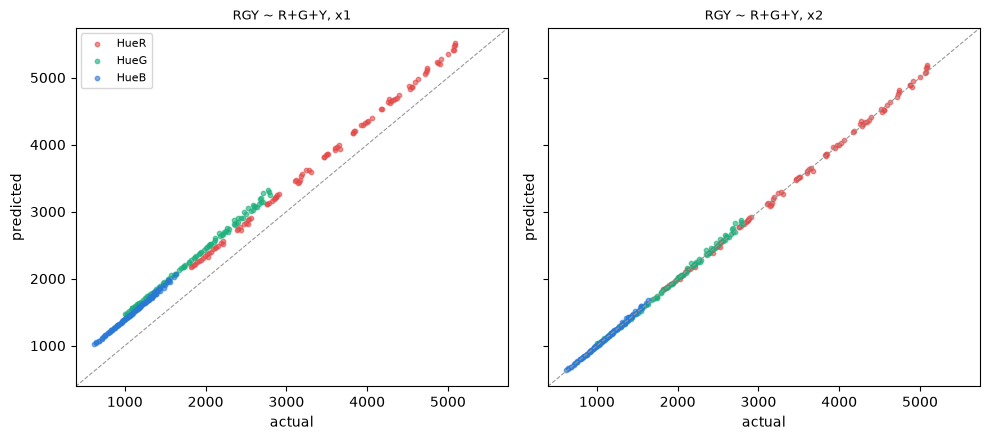

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for ax, label in zip(axes, ['RGY ~ R+G+Y, x1', 'RGY ~ R+G+Y, x2']):
    pred = predictions[label]
    for channel in plotting.CORE_CHANNELS:
        ax.scatter(pred[f'{channel}_actual'], pred[f'{channel}_predicted'], s=10, alpha=0.6, color=plotting.CHANNEL_COLORS.get(channel), label=channel)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, color='0.6', linewidth=0.8, linestyle='--')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('actual'); ax.set_ylabel('predicted'); ax.set_title(label, fontsize=9)
axes[0].legend(fontsize=8)
fig.tight_layout()

Flat `-NN` (`x1`, left) sits uniformly *above* the diagonal across all three channels -- exactly what under-subtracting is: summing three conditions that each already include one copy of the NN offset, then only removing one copy back out, leaves two extra copies baked into every point regardless of channel. `-2*NN` (`x2`, right) collapses all three channels onto the diagonal, scattered by an amount that looks consistent with the repeatability floor rather than a systematic miss.

## M3: per-trial agreement, not just aggregate residuals

The residual table and scatter above summarize agreement across the whole grid; this section plots actual vs. predicted directly against `grid_index` (trial order) for the four primary two- and three-component combinations (`GY~G+Y`, `RY~R+Y`, `RG~R+G`, each `offset_multiplier=1`; `RGY~R+G+Y`, `offset_multiplier=2`, the fit confirmed above) -- actual in each channel's own color, predicted in black, one panel per channel via `plotting.plot_prediction_trials`.

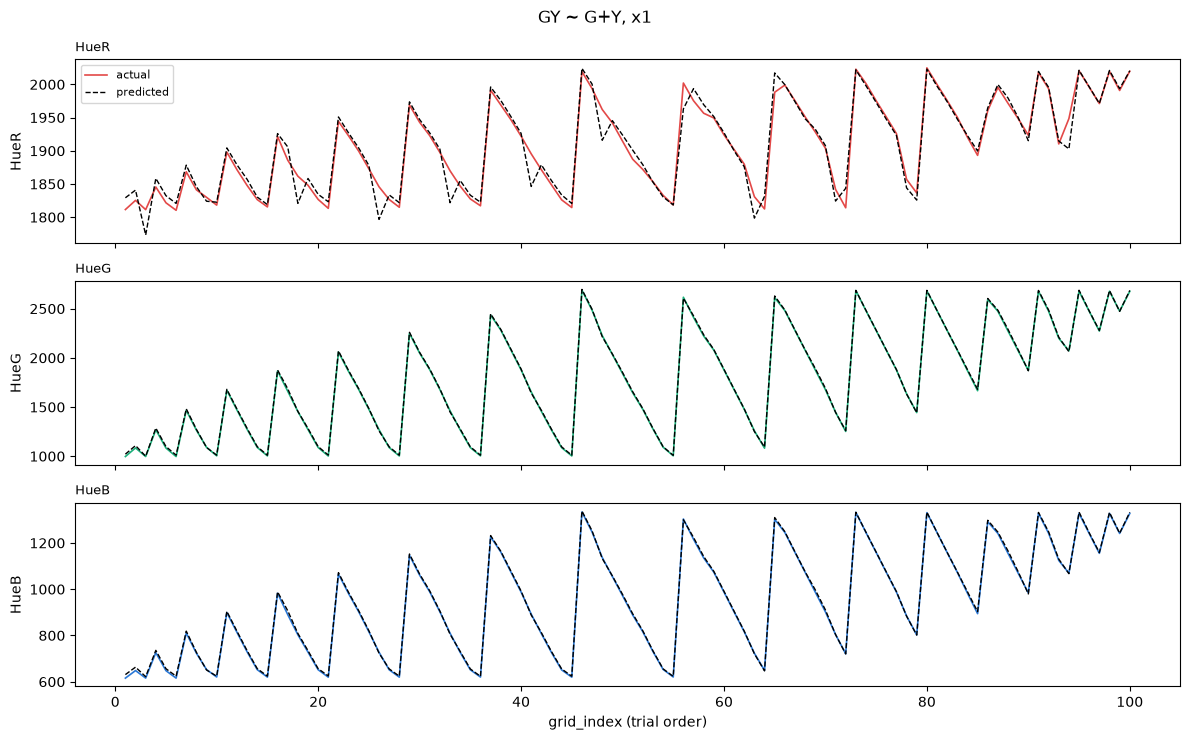

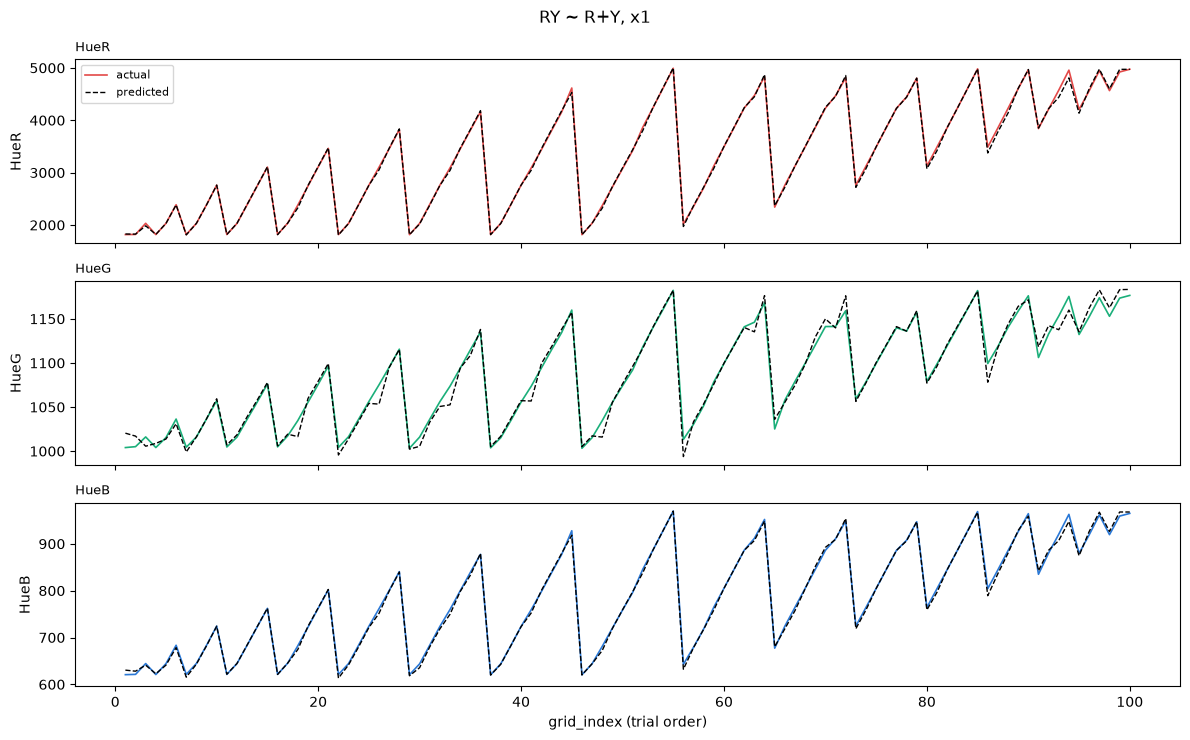

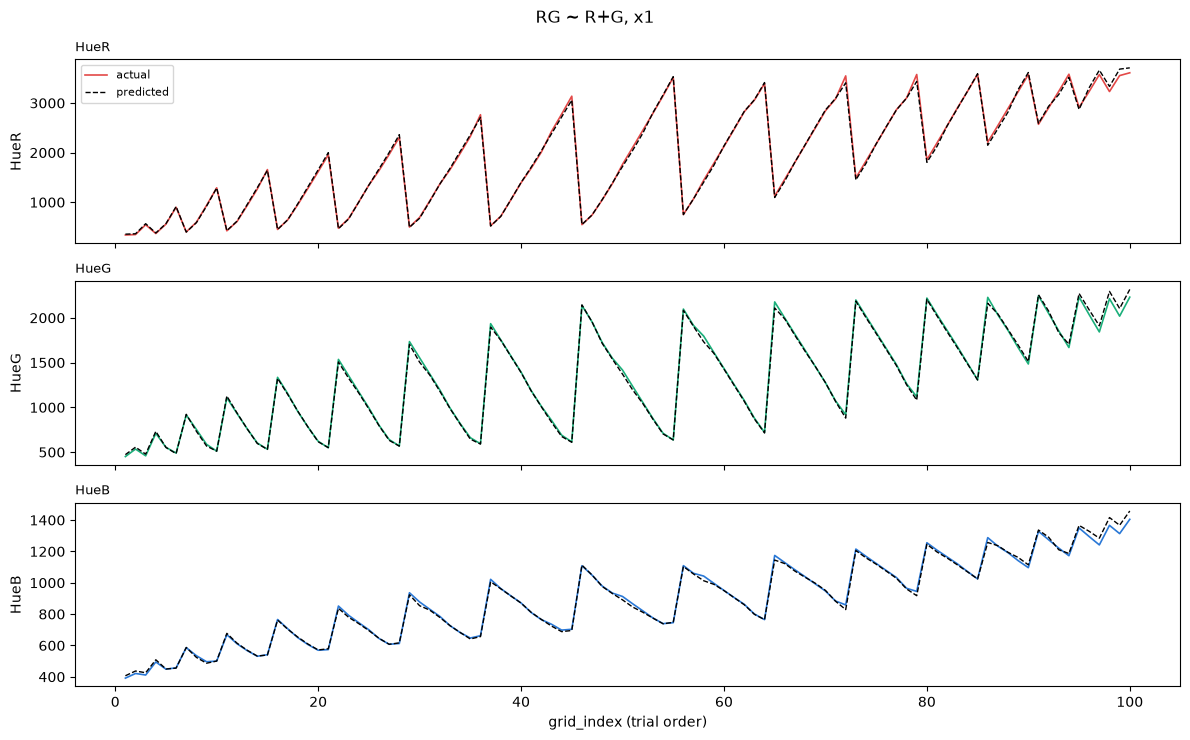

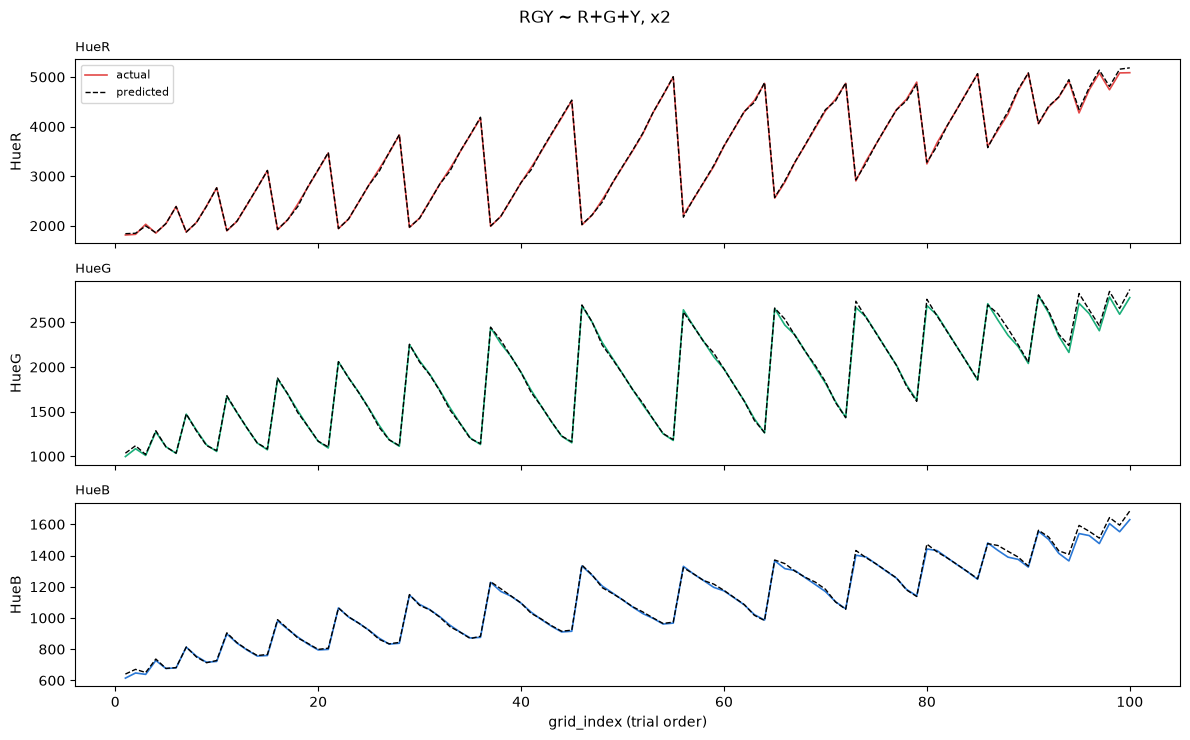

In [4]:
PRIMARY = [
    ('GY ~ G+Y, x1', ['G', 'Y'], 'GY', 1),
    ('RY ~ R+Y, x1', ['R', 'Y'], 'RY', 1),
    ('RG ~ R+G, x1', ['R', 'G'], 'RG', 1),
    ('RGY ~ R+G+Y, x2', ['R', 'G', 'Y'], 'RGY', 2),
]

for label, components, target, offset_multiplier in PRIMARY:
    plotting.plot_prediction_trials(predictions[label], title=label)

The predicted (black, dashed) line tracks the actual condition's sawtooth shape trial-by-trial, not just on average -- every peak and trough in the grid sequence (the same non-raster grid ordering `hue/README.md` documents) is reproduced by summing the component conditions, for all four combinations and across all three channels. `GY`'s `HueG`/`HueB` panels and `RGY`'s panels overlap almost exactly; the visible daylight is small, consistent jitter (a few percent of each channel's own range) rather than a systematic shape mismatch -- e.g. `GY`'s `HueR` panel (small dynamic range, ~1800-2020) shows the least-flashed channel's proportionally larger relative noise, matching the residual table above. This is the strongest evidence yet for additivity: agreement holds *across the whole grid sequence*, not just in aggregate.

### The remaining candidates, same per-trial view

The three candidates from the summary table above that weren't plotted yet: the flat `-NN` `RGY~R+G+Y` case that badly failed the aggregate residual check (as a visual contrast to the corrected `x2` version above), and the two alternate `RGY` decompositions the working hypothesis names (`RG+Y`, `RY+G`).

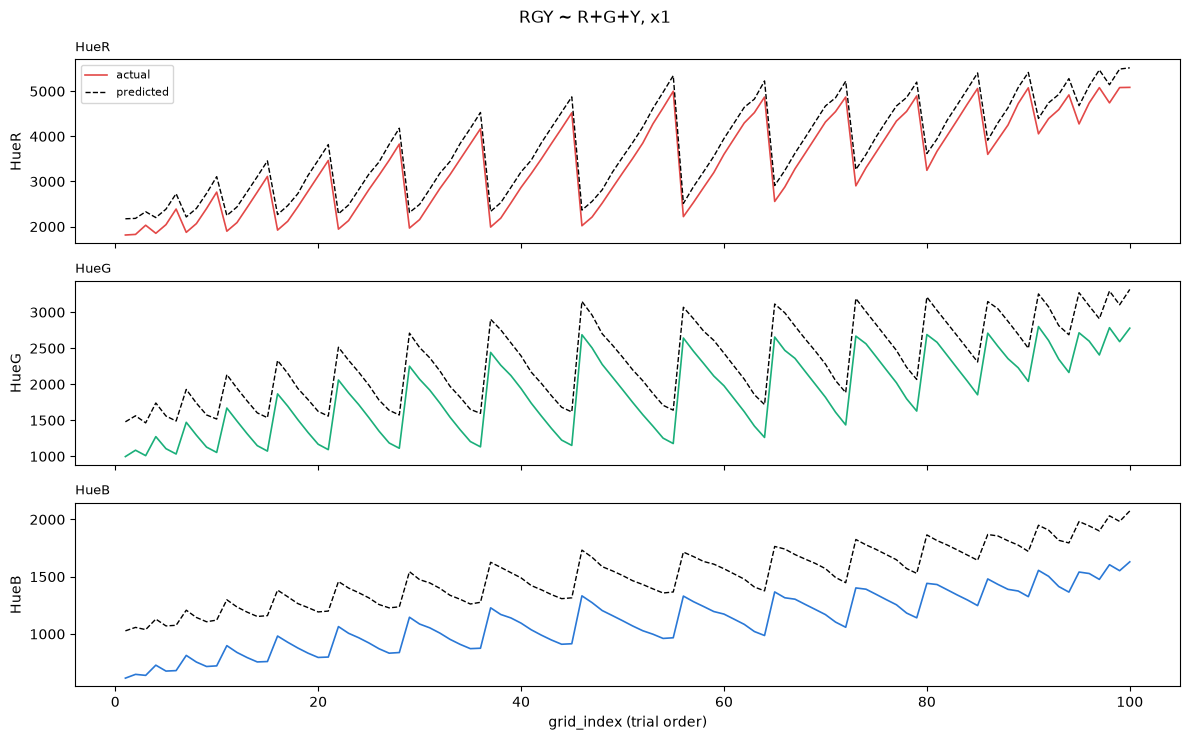

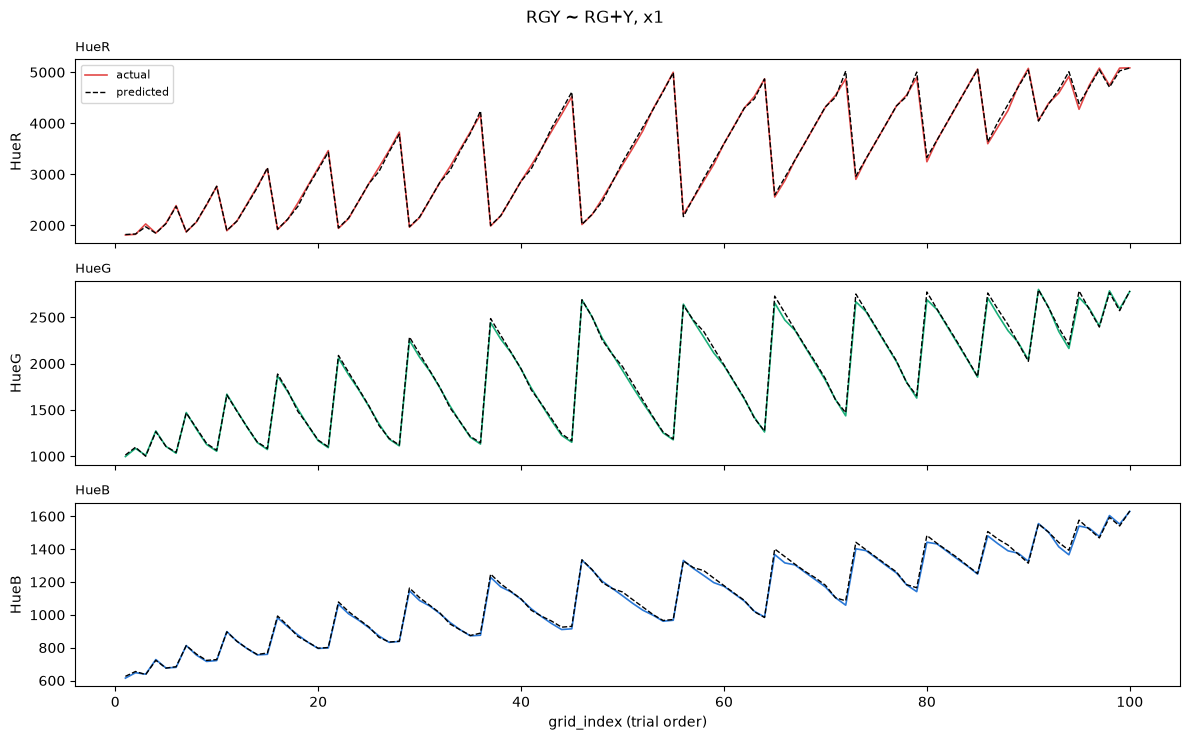

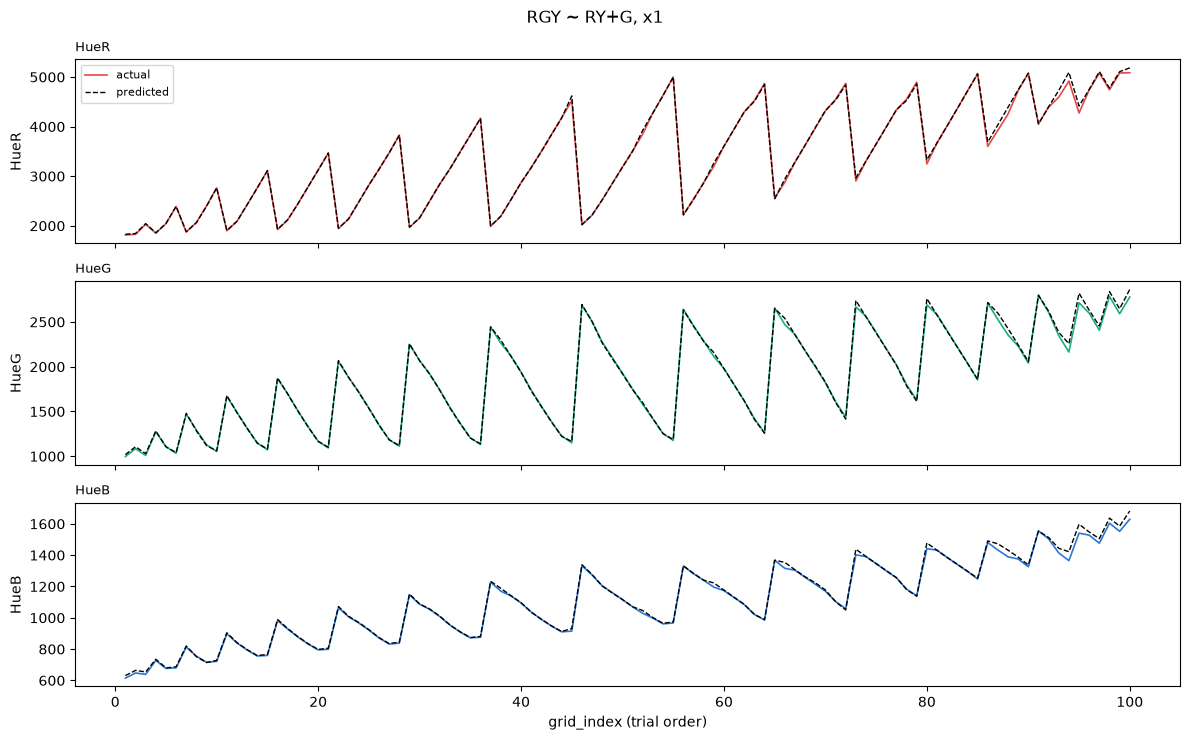

In [5]:
REMAINING = ['RGY ~ R+G+Y, x1', 'RGY ~ RG+Y, x1', 'RGY ~ RY+G, x1']

for label in REMAINING:
    plotting.plot_prediction_trials(predictions[label], title=label)

The flat `-NN` `RGY~R+G+Y` case makes the earlier scatter-plot finding concrete: predicted (black) tracks actual's exact sawtooth shape the whole way across the grid, just shifted uniformly above it -- a clean constant-offset error (one under-subtracted `NN` copy), not a shape mismatch. That's consistent with an additive model with the wrong offset, not a broken model.

Both alternate decompositions (`RG+Y`, `RY+G`, each with the correct single `-NN`) track actual as closely as `R+G+Y, x2` did across the full trial sequence, matching their similarly small residuals from the summary table. No decomposition is distinguishable from the others by eye here -- further support that this is genuine additivity rather than one specific grouping being privileged.

## Trial-order view of the same conditions

`plot_channel_trials` (M2): `R`, `G`, `Y`, `NN`, `RGY`, in grid-index order, baseline blocks included as markers past the grid trials.

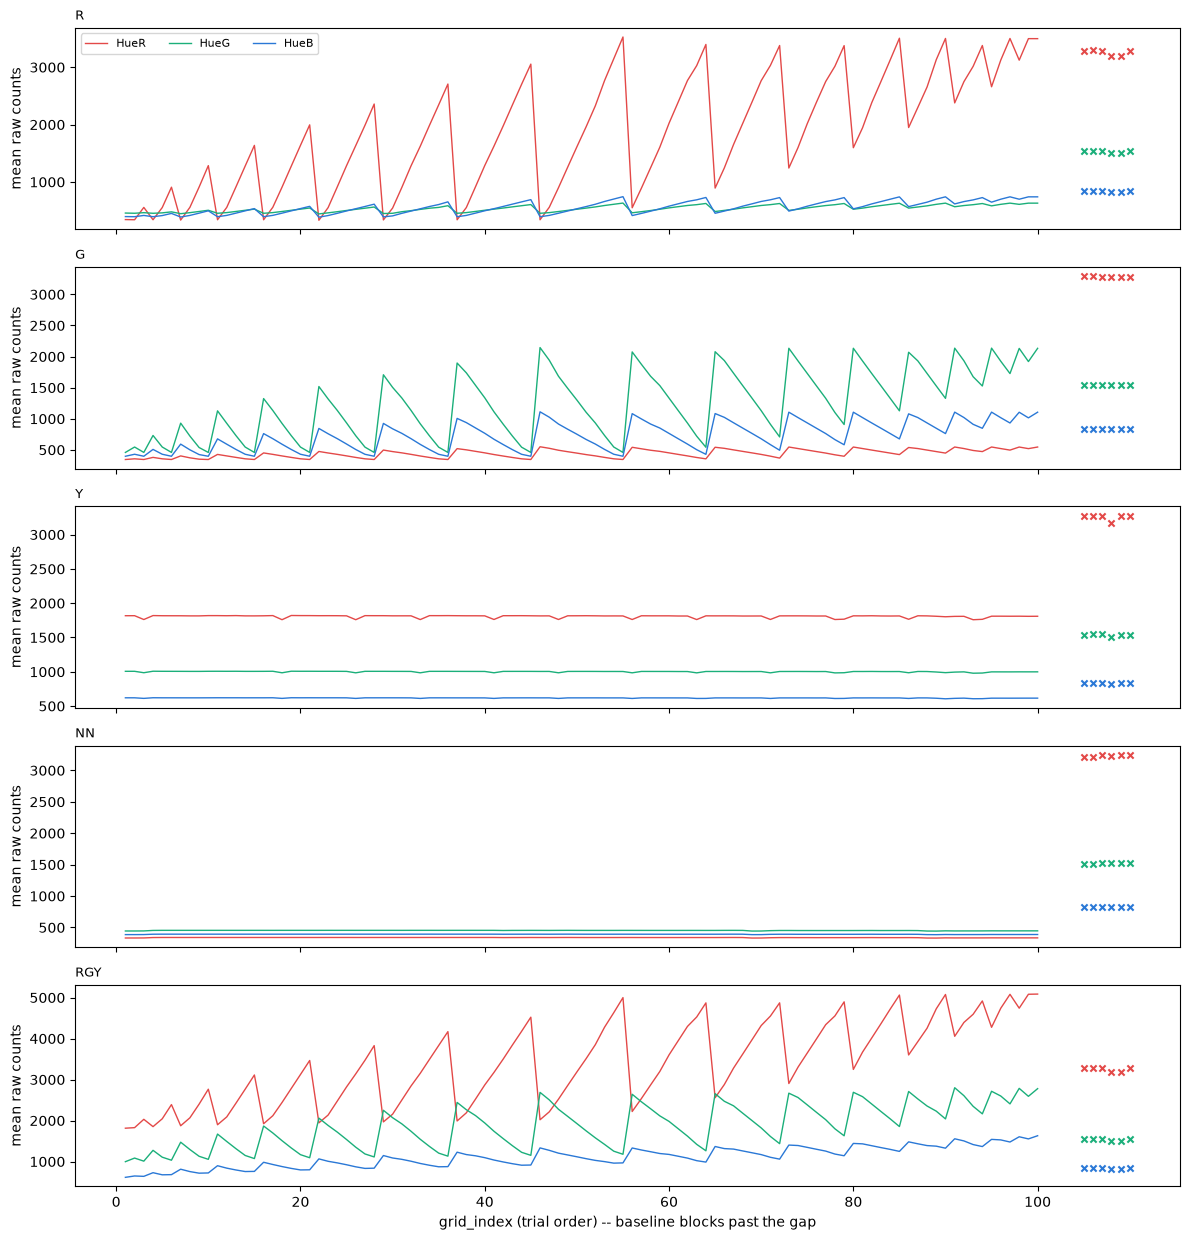

In [6]:
linear_view = agg.copy()
plotting.plot_channel_trials(linear_view, group_col='condition', groups=['R', 'G', 'Y', 'NN', 'RGY'], show_baseline=True);

## Next

`R+G+Y - 2*NN` (or `RY+G - NN`, about equally good here) is a working additive model for `RGY`, at the same order of magnitude as this sensor's own run-to-run noise -- worth promoting once cross-checked (does the same `(k-1)*NN` rule hold for `filters/`'s conditions too, not just `flashDiff/`? does a per-channel rather than shared `offset_multiplier` fit any better, given `HueR`'s residuals run consistently higher than `HueG`/`HueB`'s?) before relating any of this to `ssveps/`'s own response grids, per `PLANhue.md`.